In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
def init_transform() :
    return np.identity(3,dtype=float)

In [3]:
def centroid_image(img):
    r,c  = img.shape
    return (int(r/2),int(c/2)) 

In [4]:
def matrix_translate(T,tx,ty) :
    t = np.identity(3,dtype=float)
    t[2,0] = tx
    t[2,1] = ty
    return np.matmul(t,T)

In [5]:
def matrix_scaling(T,sx,sy) :
    s = np.identity(3,dtype=float)
    s[0,0] = sx
    s[1,1] = sy
    return np.matmul(s,T)

In [6]:
def matrix_rotate(T,degree) :
    R = np.identity(3,dtype=float)
    degree = (degree*np.pi)/180
    R[0,0] = math.cos(degree)
    R[0,1] = -math.sin(degree)
    R[1,0] = math.sin(degree)
    R[1,1] = math.cos(degree)
    return np.matmul(R,T)

In [7]:
def img_transform(img, T):
    out = np.zeros_like(img, dtype='uint8')
    rows, cols = img.shape
    for y in range(rows):
        for x in range(cols):
            xy = np.array([x, y, 1], dtype = float)
            new_xy = np.matmul(xy, T)
            xn = int(new_xy[0])
            yn = int(new_xy[1])
            if 0 <= xn < cols and 0 <= yn < rows:
                out[yn,xn] = img[y,x]
    return out.astype(np.uint8)

(512, 512)


[ WARN:0@0.217] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@0.217] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@0.217] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@0.217] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@0.217] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@0.217] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@0.217] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@0.217] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

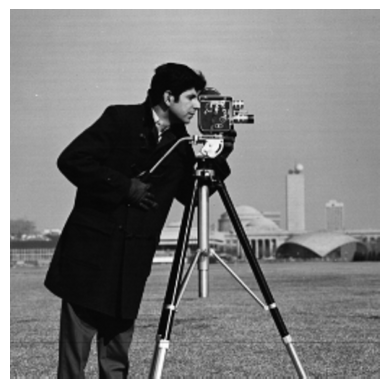

In [8]:
img = cv2.imread('../image/cameraman.tif',0)
cen = centroid_image(img)
print(img.shape)
plt.imshow(img,cmap='gray')
plt.axis('off')
plt.show()

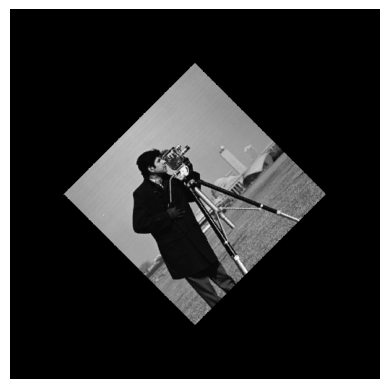

In [11]:
T = init_transform()
T = matrix_translate(T, cen[1], cen[0])
T = matrix_scaling(T, 0.5, 0.5)
T = matrix_rotate(T,45)
T  = matrix_translate(T, -cen[1], -cen[0])
new_img = img_transform(img,T)
plt.imshow(new_img , cmap='gray')
plt.axis('off')
plt.show()